UCI Diabetes Dataset
   Glucose  BloodPressure        BMI  Age  Outcome
0      182             62  43.064601   26        1
1      131             81  29.560972   44        0
2      172             56  44.099680   64        1
3       94             71  44.017739   23        0
4      186             77  41.031255   55        1

Pima Indians Diabetes Dataset
   Glucose  BloodPressure        BMI  Age  Outcome
0       96             51  30.172663   44        0
1      163             64  21.057427   37        0
2      167             60  44.590712   44        1
3      148             57  40.650248   31        1
4      113             75  21.365892   34        0

Linear Regression (Glucose -> BMI)
R2 Score: 0.0035


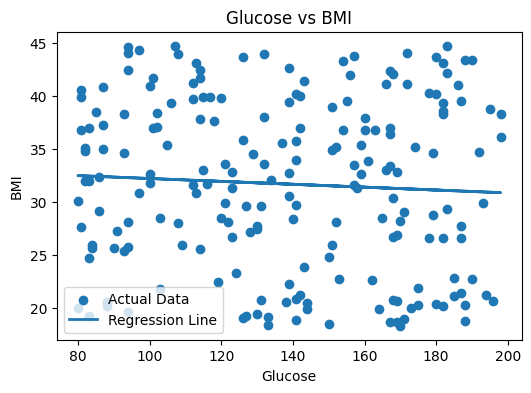


Linear Regression (Glucose -> BMI)
R2 Score: 0.0011


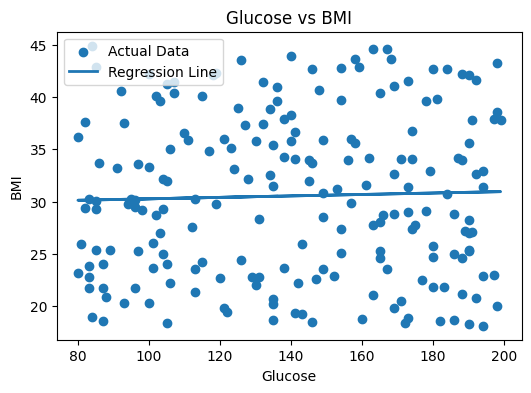


Logistic Regression - UCI Diabetes
Accuracy Score: 0.95

Logistic Regression - Pima Diabetes
Accuracy Score: 0.825

Experiment Completed Successfully!


In [1]:
# ============================================================
# Experiment 6: Linear Regression and Logistic Regression
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score

np.random.seed(42)

def create_dataset(rows=200):
    df = pd.DataFrame({
        "Glucose": np.random.randint(80, 200, rows),
        "BloodPressure": np.random.randint(50, 100, rows),
        "BMI": np.random.uniform(18, 45, rows),
        "Age": np.random.randint(20, 70, rows)
    })

    # Create a random diabetes outcome (0 or 1)
    df["Outcome"] = (
        (df["Glucose"] > 140) &
        (df["BMI"] > 28)
    ).astype(int)

    return df

uci_diabetes = create_dataset()
pima_diabetes = create_dataset()

print("UCI Diabetes Dataset")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset")
print(pima_diabetes.head())

def linear_regression_analysis(df, x_column, y_column):

    X = df[[x_column]]
    Y = df[y_column]

    model = LinearRegression()

    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression ({x_column} -> {y_column})")
    print("R2 Score:", round(r2,4))

    plt.figure(figsize=(6,4))

    plt.scatter(X, Y, label="Actual Data")

    plt.plot(X, Y_pred, linewidth=2, label="Regression Line")

    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{x_column} vs {y_column}")

    plt.legend()

    plt.show()

linear_regression_analysis(uci_diabetes, "Glucose", "BMI")

linear_regression_analysis(pima_diabetes, "Glucose", "BMI")

def logistic_regression_analysis(df):

    features = ["Glucose","BloodPressure","BMI","Age"]

    X = df[features]

    Y = df["Outcome"]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.20,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print("Accuracy Score:", round(accuracy,4))

print("\nLogistic Regression - UCI Diabetes")
logistic_regression_analysis(uci_diabetes)

print("\nLogistic Regression - Pima Diabetes")
logistic_regression_analysis(pima_diabetes)

print("\nExperiment Completed Successfully!")